Target Classical Rare-Event Probability: 1.41554000e-02
Total Quantum States Sampled: 1024


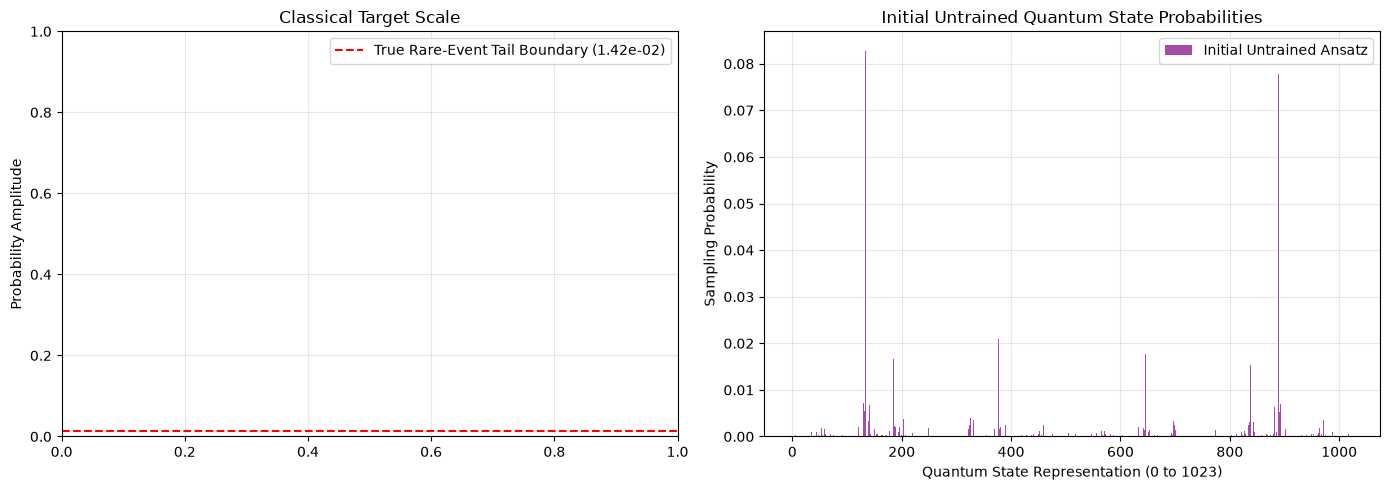

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

p_true = np.load("outputs/ground_truth_baseline.npy")
q_probs = np.load("quantum_outputs/initial_quantum_probs.npy")

print(f"Target Classical Rare-Event Probability: {p_true:.8e}")
print(f"Total Quantum States Sampled: {len(q_probs)}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# left subplot: classical target line
ax[0].axhline(p_true, color='red', linestyle='--', label=f'True Rare-Event Tail Boundary ({p_true:.2e})')
ax[0].set_title("Classical Target Scale")
ax[0].set_ylabel("Probability Amplitude")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# right subplot: uniform un-optimized quantum initial amplitudes
ax[1].bar(range(len(q_probs)), q_probs, color='purple',alpha=0.7, label='Initial Untrained Ansatz')
ax[1].set_title("Initial Untrained Quantum State Probabilities")
ax[1].set_xlabel("Quantum State Representation (0 to 1023)")
ax[1].set_ylabel("Sampling Probability")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.savefig("figures/initial_comparision.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Classical Target Baseline Probability (Cumulative): 1.4155e-02
Initial Untrained Quantum Weight in Failure Regime:  4.1962e-01


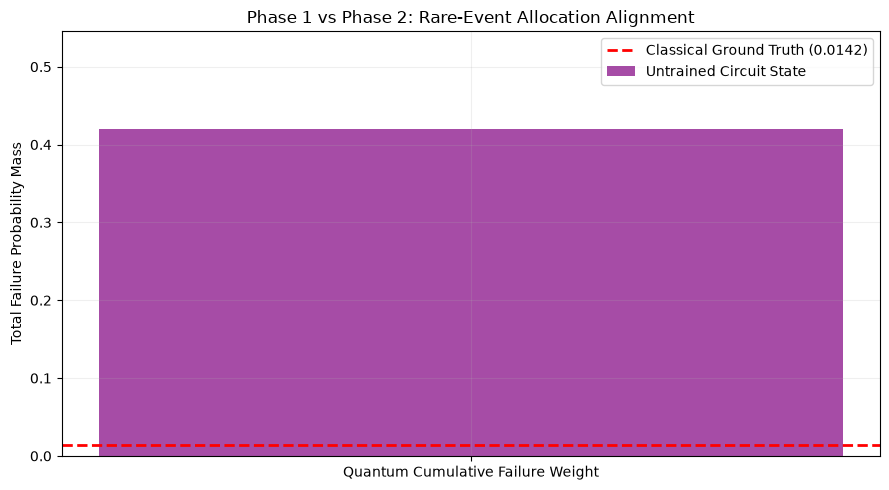

In [3]:
import numpy as np
import matplotlib.pyplot as plt

p_true_classical = np.load("outputs/ground_truth_baseline.npy")
q_probs_initial = np.load("quantum_outputs/initial_quantum_probs.npy")

# assuming a threshold where states with high bit counts match failure states
num_qubits = 10
quantum_failure_weight = 0.0

for state_idx in range(len(q_probs_initial)):
    binary_string = f"{state_idx:0{num_qubits}b}"
    
    # arbitrary rule: if the state has more than 5 active load variables (1s), it is failure
    if binary_string.count('1') > 5:
        quantum_failure_weight += q_probs_initial[state_idx]

print(f"Classical Target Baseline Probability (Cumulative): {p_true_classical:.4e}")
print(f"Initial Untrained Quantum Weight in Failure Regime:  {quantum_failure_weight:.4e}")

plt.figure(figsize=(9, 5))

plt.axhline(p_true_classical, color='red', linestyle='--', linewidth=2, 
            label=f'Classical Ground Truth ({p_true_classical:.4f})')

# quantum sampling performance as a single bar for cumulative failure weight
plt.bar(['Quantum Cumulative Failure Weight'], [quantum_failure_weight], 
        color='purple', alpha=0.7, width=0.4, label='Untrained Circuit State')

plt.ylim(0, max(p_true_classical, quantum_failure_weight) * 1.3)
plt.title("Phase 1 vs Phase 2: Rare-Event Allocation Alignment")
plt.ylabel("Total Failure Probability Mass")
plt.grid(True, alpha=0.2)
plt.legend()

plt.savefig("figures/p1p2_comparison.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

**Creating Quantum Ansatz Schematic**

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import os

draw_dev = qml.device("default.qubit", wires=4)

@qml.qnode(draw_dev)
def shortened_circuit_drawer(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.RY(params[2], wires=2)
    qml.RY(params[3], wires=3)
    
    # CNOT cascading chain motif with explicit jump to 9
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    return qml.probs(wires=range(4))

dummy_params = np.array([0.1, 0.2, 0.3, 0.4])
fig, ax = qml.draw_mpl(shortened_circuit_drawer, style="pennylane")(dummy_params)

labels = [r"$q_0$", r"$q_1$", r"$\vdots$", r"$q_9$"]
for i, label in enumerate(labels):
    ax.texts[i].set_text(label)
    ax.texts[i].set_fontsize(12)
    ax.texts[i].set_fontweight('bold')

fig.suptitle("Phase 2 Ansatz: Single Layer Structural Motif (Compressed)", fontsize=13, fontweight='bold', y=0.95)

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/qc_schematic_shortened.png", dpi=300, bbox_inches='tight')
plt.show()
print("[Success] Exported compressed circuit image to outputs/qc_schematic_shortened.png")

**Comparisons of Untrained State to Fully Optimized Quantum Distribution**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# 1. Setup the quantum environment structures
num_qubits = 10
dev = qml.device("default.qubit", wires=num_qubits)

failure_state_mask = np.zeros(2**num_qubits)
for state_idx in range(2**num_qubits):
    binary_string = f"{state_idx:0{num_qubits}b}"
    if binary_string.count('1') > 5:
        failure_state_mask[state_idx] = 1.0

@qml.qnode(dev)
def variational_circuit(circuit_parameters):
    for layer in range(circuit_parameters.shape[0]):
        for qubit in range(num_qubits):
            qml.RY(circuit_parameters[layer, qubit], wires=qubit)
        for qubit in range(num_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])
    return qml.probs(wires=range(num_qubits))

target_p = float(np.load("outputs/ground_truth_baseline.npy"))
initial_probs = np.load("quantum_outputs/initial_quantum_probs.npy")
optimized_weights = np.load("outputs/optimized_weights.npy")

initial_failure_weight = np.dot(initial_probs, failure_state_mask)
optimized_probs = variational_circuit(optimized_weights)
optimized_failure_weight = np.dot(optimized_probs, failure_state_mask)

# 3. Plot Comparison
plt.figure(figsize=(10, 5))
plt.axhline(target_p, color='red', linestyle='--', linewidth=2, label=f'Classical Ground Truth ({target_p:.4f})')

categories = ['Untrained Quantum Circuit', 'Optimized Quantum Circuit (Phase 3)']
weights = [initial_failure_weight, optimized_failure_weight]

plt.bar(categories, weights, color=['purple', 'teal'], alpha=0.7, width=0.4)
plt.ylabel("Total Failure Probability Mass")
plt.title("VQIS Framework: Distribution Realignment Comparison")
plt.grid(True, alpha=0.15)
plt.legend()
plt.savefig("outputs/final_phase3_alignment.png", dpi=300, bbox_inches='tight')
plt.show()

***Spectrum of Rare Events as Defined in Computing Systems***

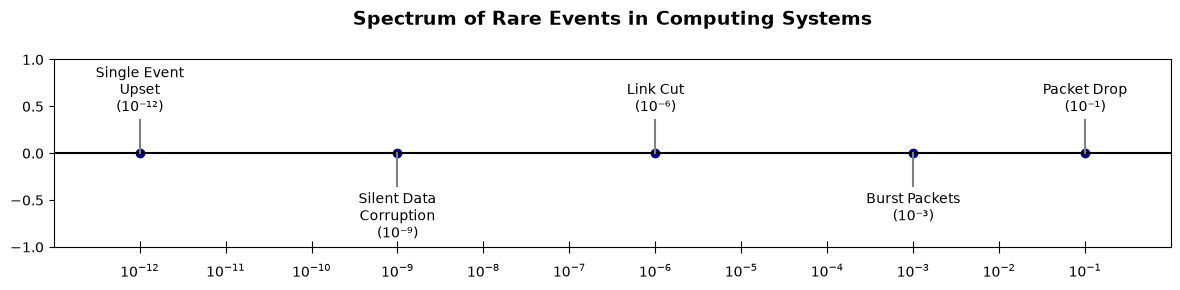

In [3]:
import matplotlib.pyplot as plt
import numpy as np

probs = [1e-1, 1e-3, 1e-6, 1e-9, 1e-12]
labels = [
    'Packet Drop\n(10⁻¹)', 
    'Burst Packets\n(10⁻³)', 
    'Link Cut\n(10⁻⁶)', 
    'Silent Data\nCorruption\n(10⁻⁹)', 
    'Single Event\nUpset\n(10⁻¹²)'
]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axhline(0, color='black')
ax.scatter(probs, [0]*len(probs), color='darkblue')

for i, (p, l) in enumerate(zip(probs, labels)):
    offset = 0.4 if i%2==0 else -0.4
    va = 'bottom' if offset > 0 else 'top'

    ax.text(p, offset, l, ha='center', va=va)

    line_end = offset - 0.05 if offset > 0 else offset + 0.05
    ax.plot([p,p], [0, line_end], color='gray')

ax.set_xscale('log')
ax.set_xlim(1e-13, 1e0)
ax.set_ylim(-1, 1)

ticks = [10**-i for i in range(1, 13)]
ax.set_xticks(ticks)
ax.tick_params(axis='x', labelsize=10, direction='inout', length=8, pad=8)

plt.title('Spectrum of Rare Events in Computing Systems', pad=25, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rare_events_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()